In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchvision.transforms.functional as tvF

import math

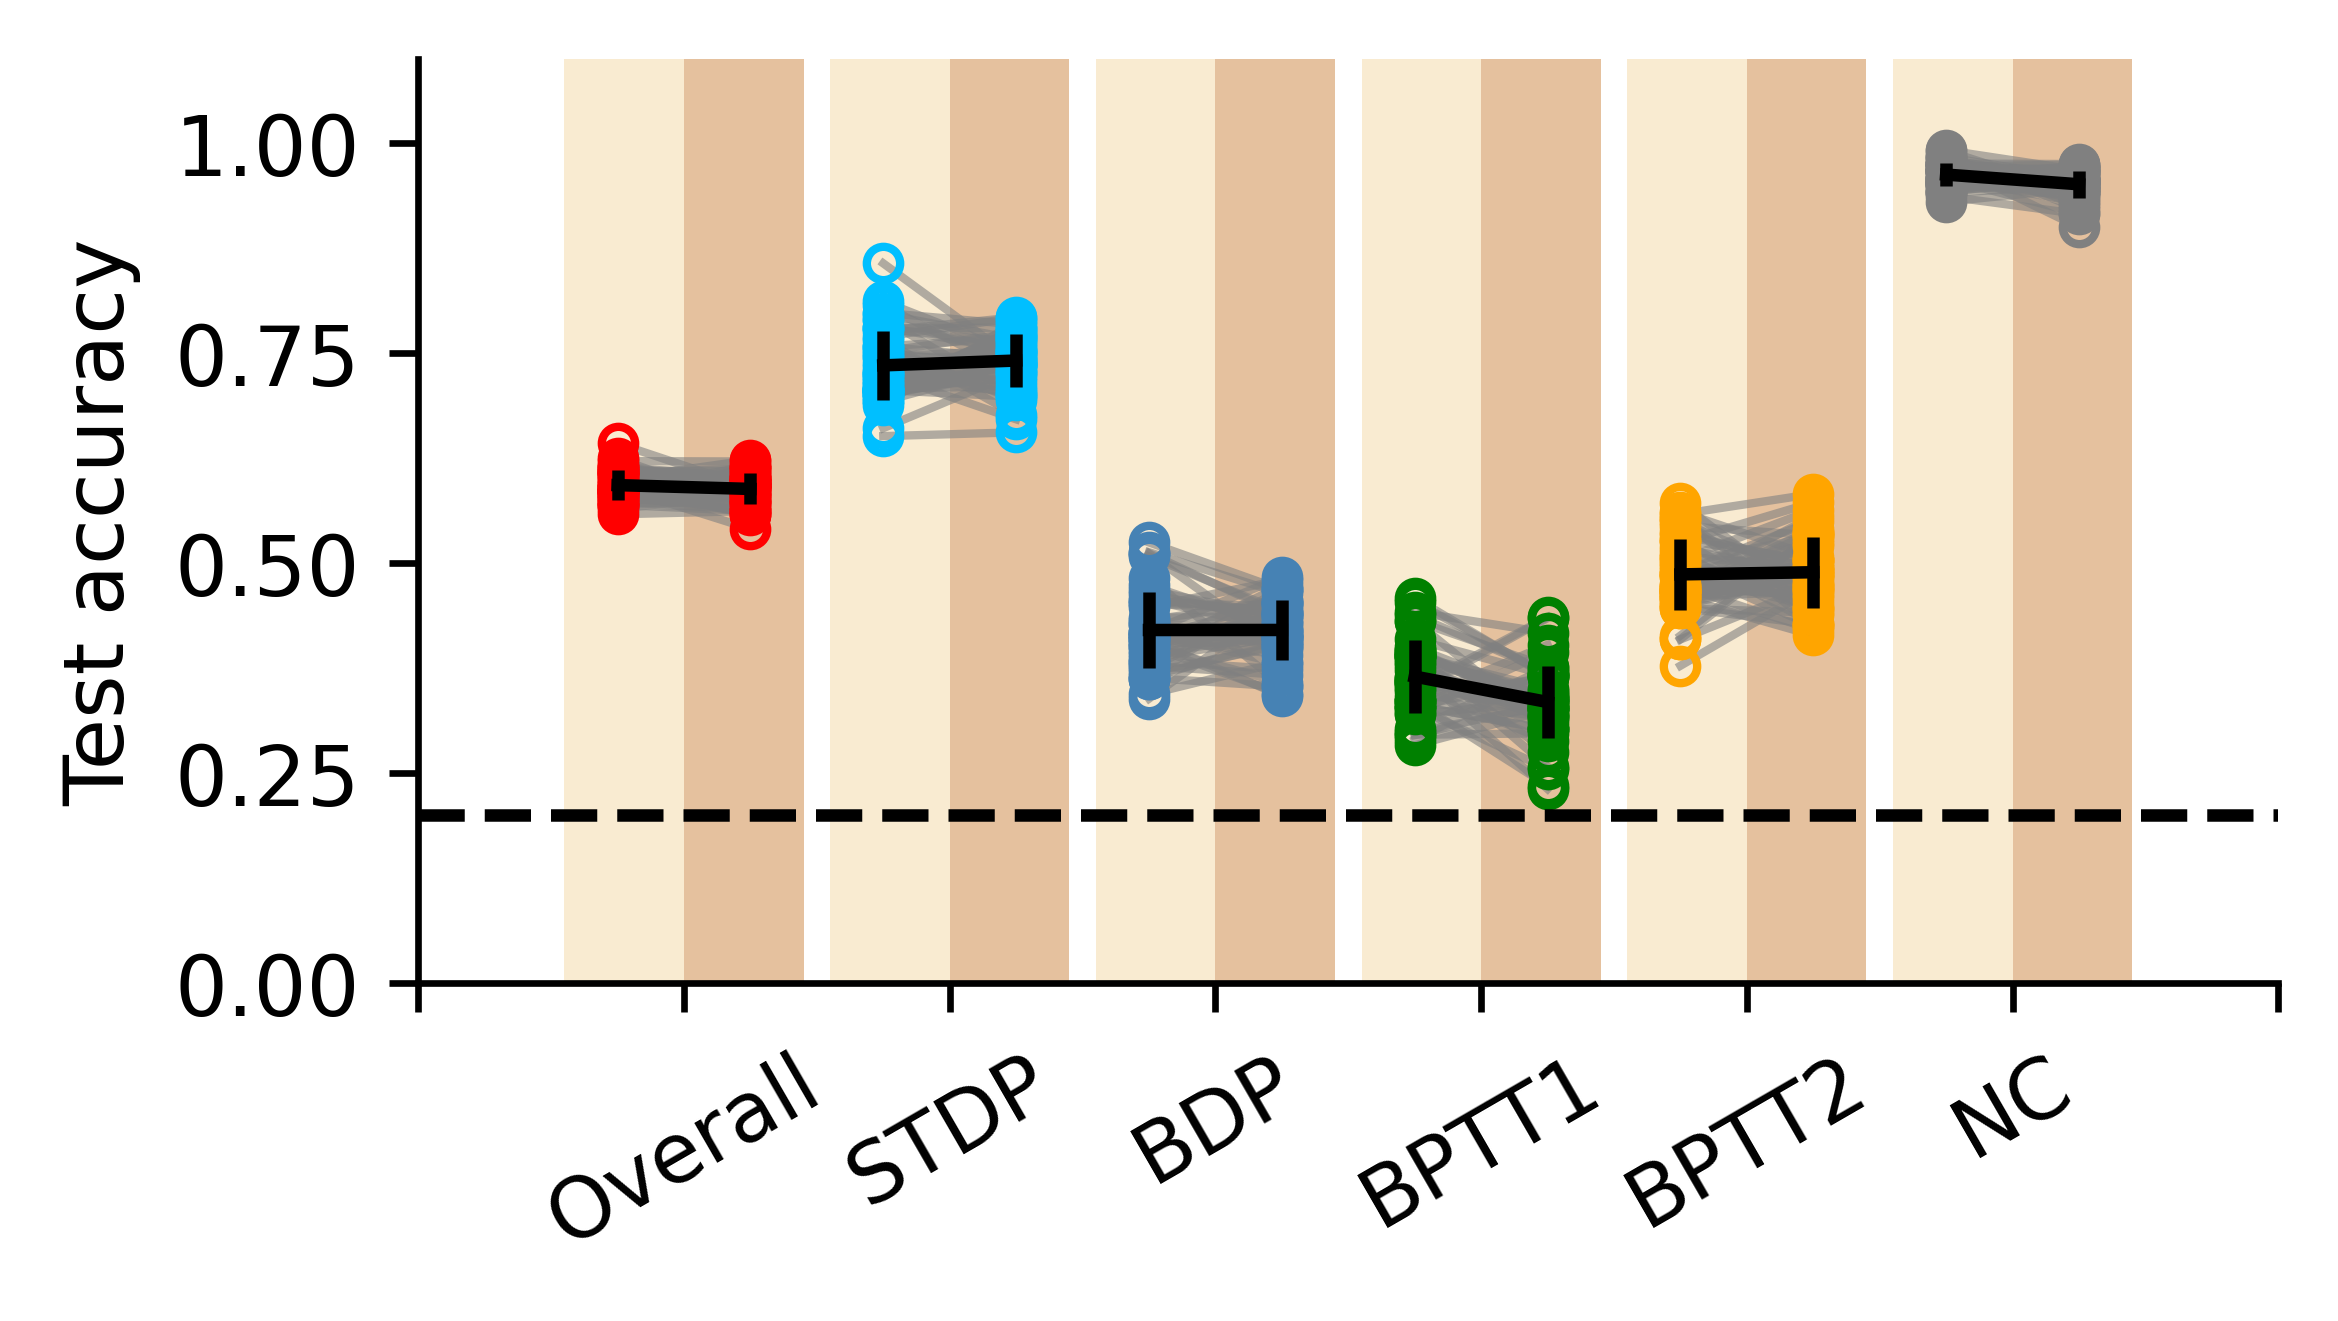

In [5]:
save_dir = '/content/drive/MyDrive/Project/PlasticityDecoding/result'
acu_set_SVM = np.load(save_dir + '/svm_fixedrepresentation.npy')
acu_set_test_SVM = np.load(save_dir + '/svm_fixedrepresentation1.npy')

from matplotlib.patches import Rectangle

color_list = ['deepskyblue', 'steelblue', 'green', 'orange', 'gray']
pos_list = [1, 2, 3, 4, 5]
pos_shift = 0.25
fig, ax = plt.subplots(figsize=(4,2), dpi=600)
ax.add_patch(Rectangle((1 - pos_shift - 0.2, 0), 0.45, 1.1, facecolor='wheat', alpha=0.6, label='In'))
ax.add_patch(Rectangle((1, 0), 0.45, 1.1, facecolor='peru', alpha=0.5, label='Out'))
plt.plot([np.ones_like(acu_set_SVM[:,0]) - pos_shift, np.ones_like(acu_set_test_SVM[:,0]) + pos_shift], [acu_set_SVM[:,0], acu_set_test_SVM[:,0]], '-', color='gray', linewidth=1.0, alpha=0.6)
plt.plot([np.ones_like(acu_set_SVM[:,0]) - pos_shift, np.ones_like(acu_set_test_SVM[:,0]) + pos_shift], [acu_set_SVM[:,0], acu_set_test_SVM[:,0]], 'ro', markerfacecolor='none', markersize=4)
plt.errorbar([1.0 - pos_shift, 1.0 + pos_shift], [acu_set_SVM[:,0].mean(), acu_set_test_SVM[:,0].mean()], yerr=[acu_set_SVM[:,0].std(), acu_set_test_SVM[:,0].std()], color='k')
for ii in range(0, 5):
    plt.plot([np.ones_like(acu_set_SVM[:,ii + 1]) + pos_list[ii] - pos_shift, np.ones_like(acu_set_test_SVM[:,ii + 1]) + pos_list[ii] + pos_shift],
            [acu_set_SVM[:,ii + 1], acu_set_test_SVM[:,ii + 1]], '-', color='gray', linewidth=1.0, alpha=0.6)
    plt.plot([np.ones_like(acu_set_SVM[:,ii + 1]) + pos_list[ii] - pos_shift, np.ones_like(acu_set_test_SVM[:,ii + 1]) + pos_list[ii] + pos_shift],
            [acu_set_SVM[:,ii + 1], acu_set_test_SVM[:,ii + 1]], 'o', color=color_list[ii], markerfacecolor='none', markersize=4)
    plt.errorbar([1 + pos_list[ii] - pos_shift, 1 + pos_list[ii] + pos_shift],
                [acu_set_SVM[:,ii + 1].mean(), acu_set_test_SVM[:,ii + 1].mean()], yerr=[acu_set_SVM[:,ii + 1].std(), acu_set_test_SVM[:,ii + 1].std()], color='k')
    ax.add_patch(Rectangle((1 + pos_list[ii] - pos_shift - 0.2, 0), 0.45, 1.1, facecolor='wheat', alpha=0.6))
    ax.add_patch(Rectangle((1 + pos_list[ii], 0), 0.45, 1.1, facecolor='peru', alpha=0.5))

plt.plot([0, 7], [0.2, 0.2], 'k--')
plt.ylim(0,1.1)
plt.xlim([0, 7])
plt.xticks(range(0,8),('','Overall','STDP','BDP','BPTT1','BPTT2','NC',''),rotation=30)
plt.ylabel('Test accuracy')
# plt.legend(loc='best')
sns.despine()
plt.show()

In [6]:
acu_set_TCNN = np.load(save_dir + '/TCNN_fixedrepresentation.npy')
acu_set_TTE = np.load(save_dir + '/TTE_fixedrepresentation.npy')


acu_set_test_TCNN = np.load(save_dir + '/TCNN_fixedrepresentation1.npy')
acu_set_test_TTE = np.load(save_dir + '/TTE_fixedrepresentation1.npy')


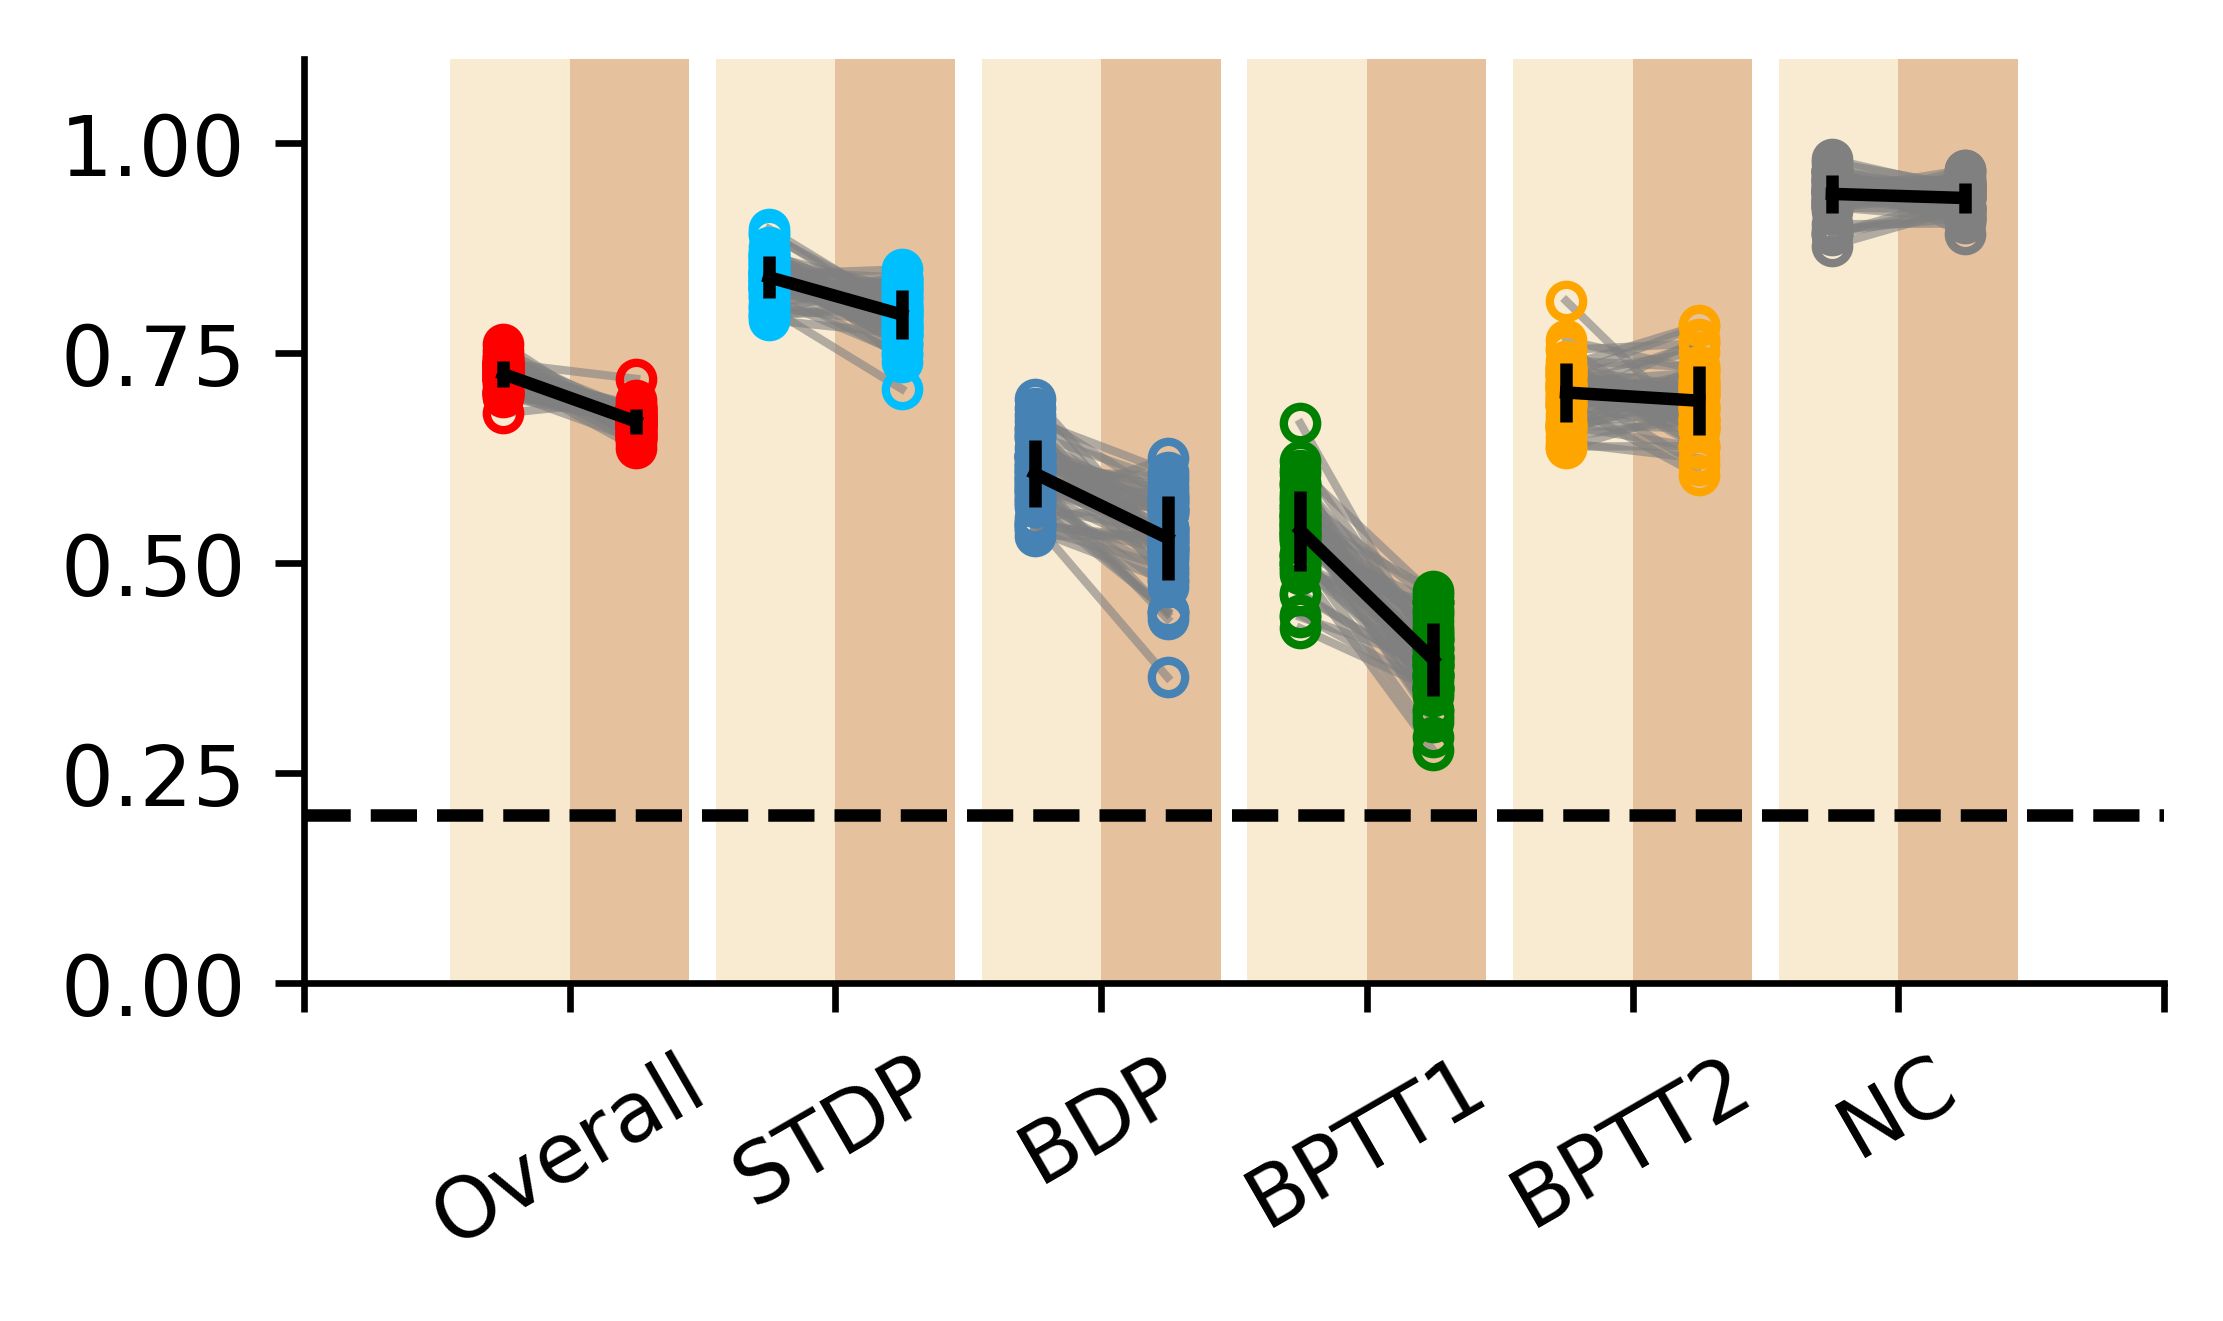

In [10]:
from matplotlib.patches import Rectangle

color_list = ['deepskyblue', 'steelblue', 'green', 'orange', 'gray']
pos_list = [1, 2, 3, 4, 5]
pos_shift = 0.25
fig, ax = plt.subplots(figsize=(4,2), dpi=600)
ax.add_patch(Rectangle((1 - pos_shift - 0.2, 0), 0.45, 1.1, facecolor='wheat', alpha=0.6, label='In'))
ax.add_patch(Rectangle((1, 0), 0.45, 1.1, facecolor='peru', alpha=0.5, label='Out'))
plt.plot([np.ones_like(acu_set_TCNN[:,1]) - pos_shift, np.ones_like(acu_set_test_TCNN[:,1]) + pos_shift], [acu_set_TCNN[:,1], acu_set_test_TCNN[:,1]], '-', color='gray', linewidth=1.0, alpha=0.6)
plt.plot([np.ones_like(acu_set_TCNN[:,1]) - pos_shift, np.ones_like(acu_set_test_TCNN[:,1]) + pos_shift], [acu_set_TCNN[:,1], acu_set_test_TCNN[:,1]], 'ro', markerfacecolor='none', markersize=4)
plt.errorbar([1.0 - pos_shift, 1.0 + pos_shift], [acu_set_TCNN[:,1].mean(), acu_set_test_TCNN[:,1].mean()], yerr=[acu_set_TCNN[:,1].std(), acu_set_test_TCNN[:,1].std()], color='k')
for ii in range(0, 5):
    plt.plot([np.ones_like(acu_set_TCNN[:,ii * 2 + 3]) + pos_list[ii] - pos_shift, np.ones_like(acu_set_test_TCNN[:,ii * 2 + 3]) + pos_list[ii] + pos_shift],
            [acu_set_TCNN[:,ii * 2 + 3], acu_set_test_TCNN[:,ii * 2 + 3]], '-', color='gray', linewidth=1.0, alpha=0.6)
    plt.plot([np.ones_like(acu_set_TCNN[:,ii * 2 + 3]) + pos_list[ii] - pos_shift, np.ones_like(acu_set_test_TCNN[:,ii * 2 + 3]) + pos_list[ii] + pos_shift],
            [acu_set_TCNN[:,ii * 2 + 3], acu_set_test_TCNN[:,ii * 2 + 3]], 'o', color=color_list[ii], markerfacecolor='none', markersize=4)
    plt.errorbar([1 + pos_list[ii] - pos_shift, 1 + pos_list[ii] + pos_shift],
                [acu_set_TCNN[:,ii * 2 + 3].mean(), acu_set_test_TCNN[:,ii * 2 + 3].mean()], yerr=[acu_set_TCNN[:,ii * 2 + 3].std(), acu_set_test_TCNN[:,ii * 2 + 3].std()], color='k')
    ax.add_patch(Rectangle((1 + pos_list[ii] - pos_shift - 0.2, 0), 0.45, 1.1, facecolor='wheat', alpha=0.6))
    ax.add_patch(Rectangle((1 + pos_list[ii], 0), 0.45, 1.1, facecolor='peru', alpha=0.5))

plt.plot([0, 7], [0.2, 0.2], 'k--')
plt.ylim(0,1.1)
plt.xlim([0, 7])
plt.xticks(range(0,8),('','Overall','STDP','BDP','BPTT1','BPTT2','NC',''),rotation=30)
# plt.ylabel('Test accuracy')
# plt.legend(loc='best')
sns.despine()
plt.show()

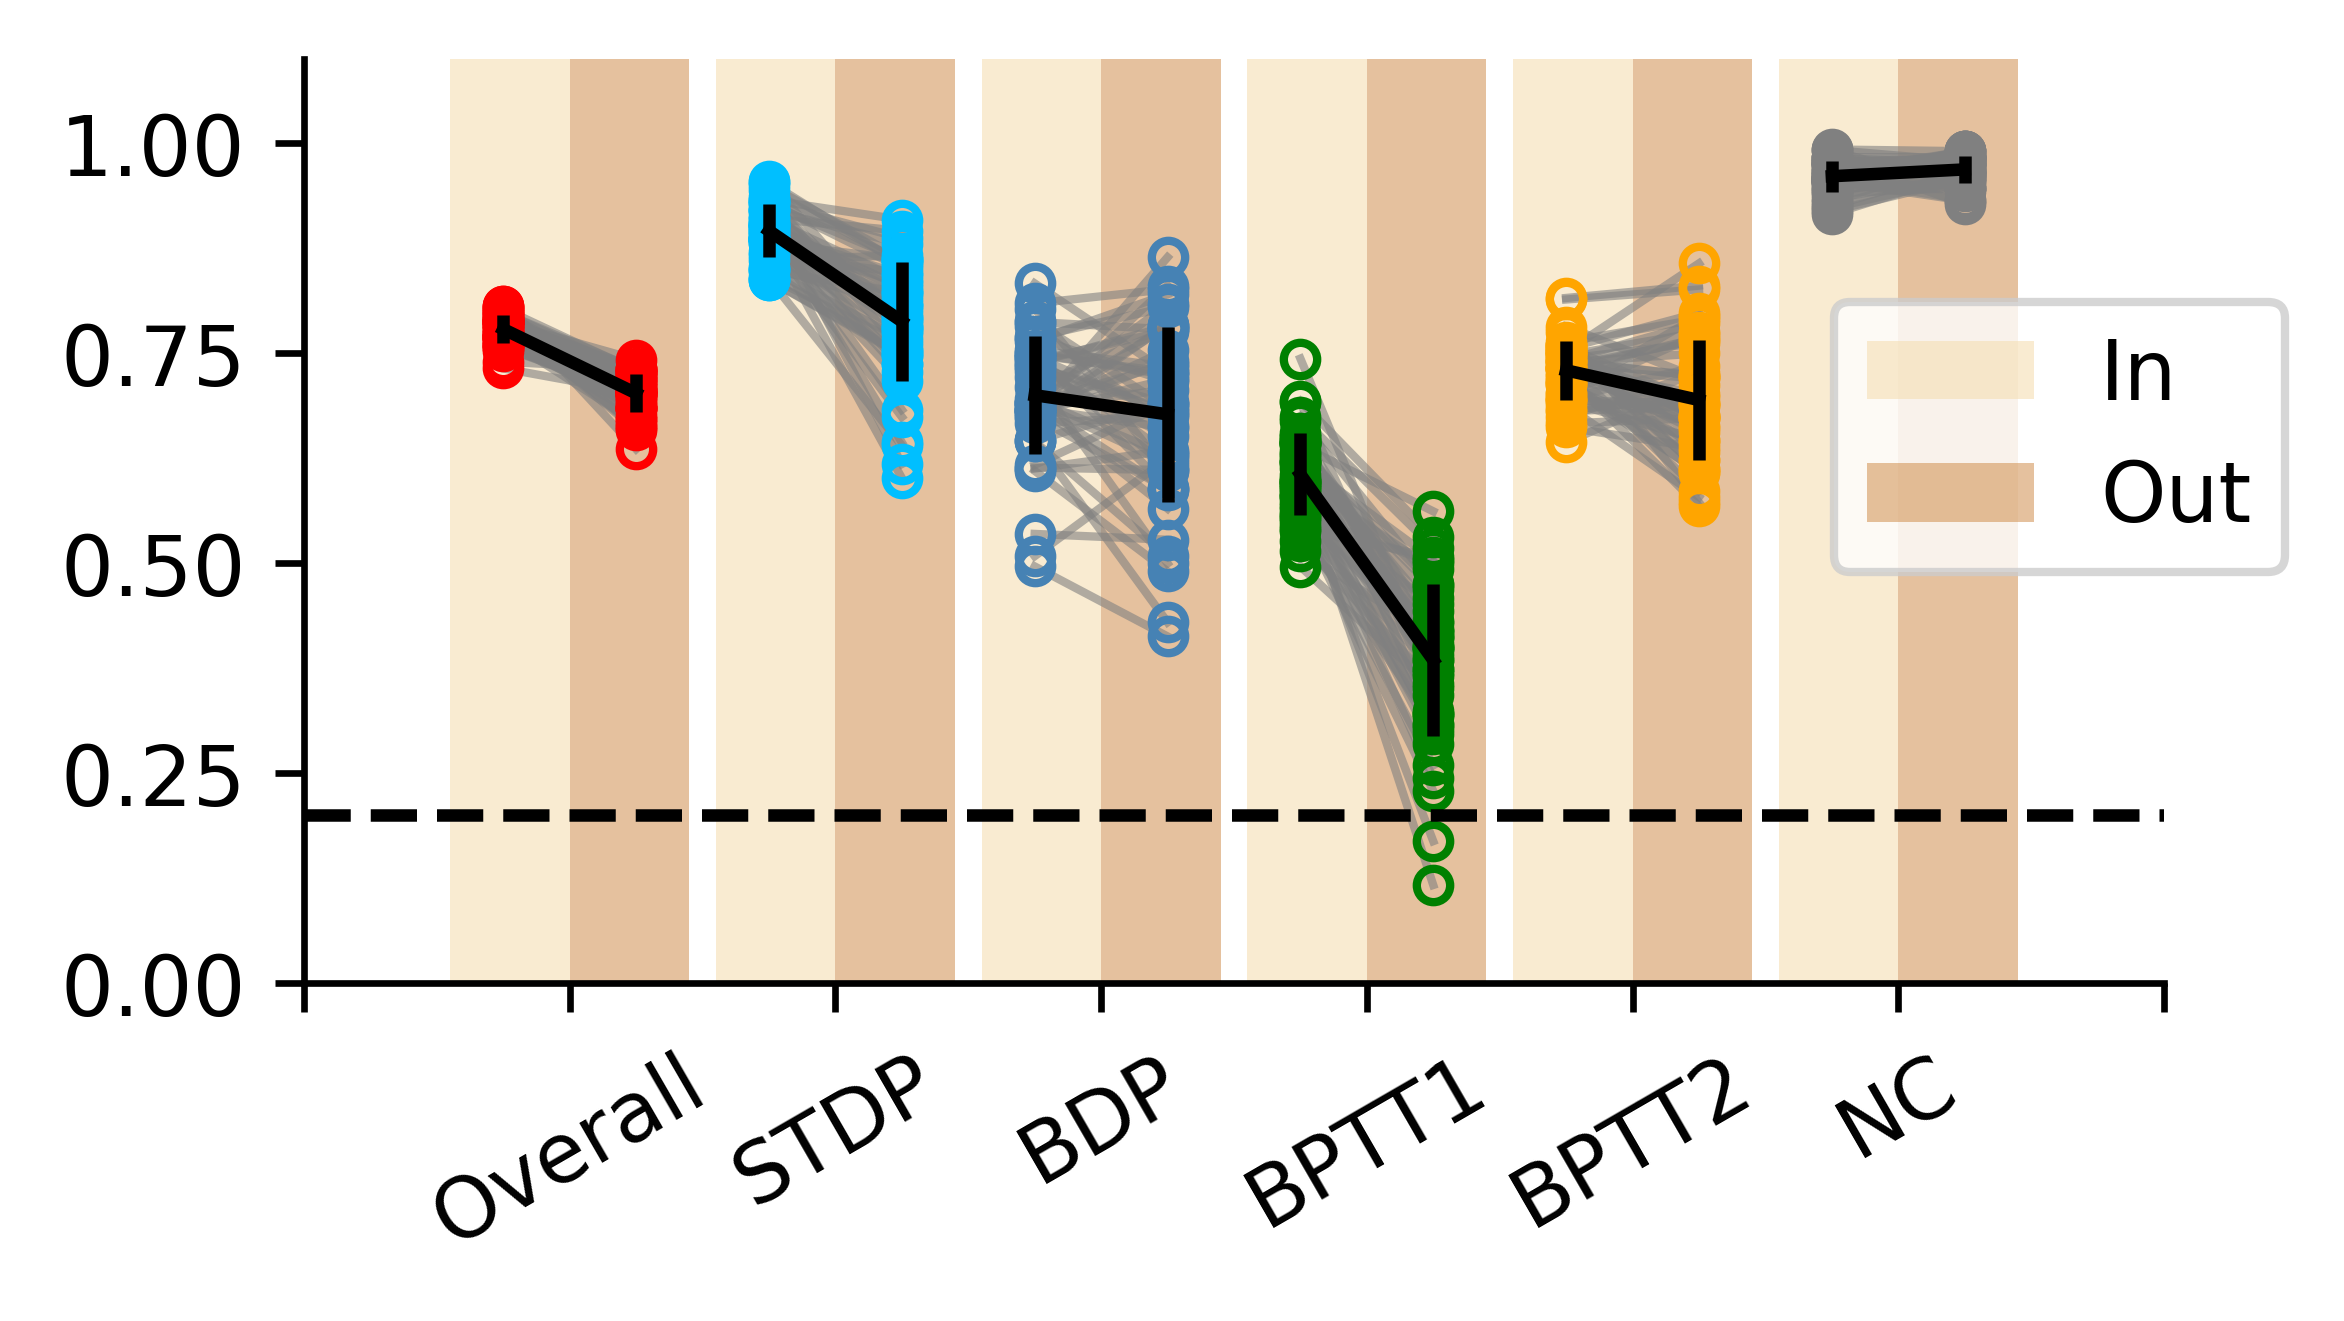

In [9]:
from matplotlib.patches import Rectangle

color_list = ['deepskyblue', 'steelblue', 'green', 'orange', 'gray']
pos_list = [1, 2, 3, 4, 5]
pos_shift = 0.25
fig, ax = plt.subplots(figsize=(4,2), dpi=600)
ax.add_patch(Rectangle((1 - pos_shift - 0.2, 0), 0.45, 1.1, facecolor='wheat', alpha=0.6, label='In'))
ax.add_patch(Rectangle((1, 0), 0.45, 1.1, facecolor='peru', alpha=0.5, label='Out'))
plt.plot([np.ones_like(acu_set_TTE[:,1]) - pos_shift, np.ones_like(acu_set_test_TTE[:,1]) + pos_shift], [acu_set_TTE[:,1], acu_set_test_TTE[:,1]], '-', color='gray', linewidth=1.0, alpha=0.6)
plt.plot([np.ones_like(acu_set_TTE[:,1]) - pos_shift, np.ones_like(acu_set_test_TTE[:,1]) + pos_shift], [acu_set_TTE[:,1], acu_set_test_TTE[:,1]], 'ro', markerfacecolor='none', markersize=4)
plt.errorbar([1.0 - pos_shift, 1.0 + pos_shift], [acu_set_TTE[:,1].mean(), acu_set_test_TTE[:,1].mean()], yerr=[acu_set_TTE[:,1].std(), acu_set_test_TTE[:,1].std()], color='k')
for ii in range(0, 5):
    plt.plot([np.ones_like(acu_set_TTE[:,ii * 2 + 3]) + pos_list[ii] - pos_shift, np.ones_like(acu_set_test_TTE[:,ii * 2 + 3]) + pos_list[ii] + pos_shift],
           [acu_set_TTE[:,ii * 2 + 3], acu_set_test_TTE[:,ii * 2 + 3]], '-', color='gray', linewidth=1.0, alpha=0.6)
    plt.plot([np.ones_like(acu_set_TTE[:,ii * 2 + 3]) + pos_list[ii] - pos_shift, np.ones_like(acu_set_test_TTE[:,ii * 2 + 3]) + pos_list[ii] + pos_shift],
           [acu_set_TTE[:,ii * 2 + 3], acu_set_test_TTE[:,ii * 2 + 3]], 'o', color=color_list[ii], markerfacecolor='none', markersize=4)
    plt.errorbar([1 + pos_list[ii] - pos_shift, 1 + pos_list[ii] + pos_shift],
               [acu_set_TTE[:,ii * 2 + 3].mean(), acu_set_test_TTE[:,ii * 2 + 3].mean()], yerr=[acu_set_TTE[:,ii * 2 + 3].std(), acu_set_test_TTE[:,ii * 2 + 3].std()], color='k')
    ax.add_patch(Rectangle((1 + pos_list[ii] - pos_shift - 0.2, 0), 0.45, 1.1, facecolor='wheat', alpha=0.6))
    ax.add_patch(Rectangle((1 + pos_list[ii], 0), 0.45, 1.1, facecolor='peru', alpha=0.5))

plt.plot([0, 7], [0.2, 0.2], 'k--')
plt.ylim(0,1.1)
plt.xlim([0, 7])
plt.xticks(range(0,8),('','Overall','STDP','BDP','BPTT1','BPTT2','NC',''),rotation=30)
# plt.ylabel('Test accuracy')
plt.legend(loc='best', bbox_to_anchor=(0.8, 0.4))
sns.despine()
plt.show()